# Imported the Libraries

In [219]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import datetime as dt

# Reading the Files

In [220]:
cust = pd.read_csv("Customer Acqusition.csv")

In [221]:
cust.head()

,No,Customer,Age,City,Product,Limit,Company,Segment
0,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed
1,2,A2,71,CALCUTTA,Silver,100000.0,C2,Salaried_MNC
2,3,A3,34,COCHIN,Platimum,10000.0,C3,Salaried_Pvt
3,4,A4,47,BOMBAY,Platimum,10001.0,C4,Govt
4,5,A5,56,BANGALORE,Platimum,10002.0,C5,Normal Salary


In [222]:
rep = pd.read_csv("Repayment.csv")

In [223]:
rep.head()

,SL No:,Customer,Month,Amount,Unnamed: 4
0,NaN,A1,12-Jan-04,495414.75,NaN
1,2.0,A1,3-Jan-04,245899.02,NaN
2,3.0,A1,15-Jan-04,259490.06,NaN
3,4.0,A1,25-Jan-04,437555.12,NaN
4,5.0,A1,17-Jan-05,165972.88,NaN


In [224]:
spn = pd.read_csv("spend.csv")

In [225]:
spn.head()

,Sl No:,Customer,Month,Type,Amount
0,1,A1,12-Jan-04,JEWELLERY,485470.80
1,2,A1,3-Jan-04,PETRO,410556.13
2,3,A1,15-Jan-04,CLOTHES,23740.46
3,4,A1,25-Jan-04,FOOD,484342.47
4,5,A1,17-Jan-05,CAMERA,369694.07


 ## Q1. In the above dataset,
#### a. In case age is less than 18, replace it with mean of age values.
#### b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit. 
#### (customer’s limit provided in acquisition table is the per transaction limit on his card)
#### c. Incase the repayment amount is more than the limit, replace the repayment with the limit.

In [229]:
# a. In case age is less than 18, replace it with mean of age values.
# Assign specifically to the "Age" column
mean_age = cust.loc[cust["Age"] >= 18, "Age"].mean()

cust.loc[cust["Age"] < 18, "Age"] = mean_age

C:\Users\Shubham Vishwakarma\AppData\Local\Temp\ipykernel_15564\2281112228.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '48.52127659574468' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cust.loc[cust["Age"] < 18, "Age"] = mean_age


In [230]:
# b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit.
# (customer’s limit provided in acquisition table is the per transaction limit on his card)
spend = spn.merge(cust[["Customer", "Limit"]], left_on="Customer", right_on="Customer", how="left")

spend.loc[spend["Amount"] > spend["Limit"], "Amount"] = (0.5 * spend["Limit"])


In [231]:
# c. Incase the repayment amount is more than the limit, replace the repayment with the limit.
rep = rep.merge(cust[["Customer", "Limit"]], left_on="Customer", right_on="Customer", how="left")

rep.loc[rep["Amount"] > rep["Limit"], "Amount"] = rep["Limit"]


## 2. From the above dataset create the following summaries:
#### a. How many distinct customers exist?
#### b. How many distinct categories exist?
#### c. What is the average monthly spend by customers?
#### d. What is the average monthly repayment by customers?
#### e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month?
#### (Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly repayment – Monthly spend. Interest is earned only on positive profits and not on negative amounts)
 #### f. What are the top 5 product types?
 #### g. Which city is having maximum spend?
 #### h. Which age group is spending more money?
 #### i. Who are the top 10 customers in terms of repayment?

## Add Date Features

In [232]:
# converted in datetime
spn["Month"] = pd.to_datetime(spn["Month"])
rep["Month"] = pd.to_datetime(rep["Month"])

# added the year and month column in spend table 
spn["Year"] = spn["Month"].dt.year
spn["Month_num"] = spn["Month"].dt.month

# added the year and month column in repayment table
rep["Year"] = rep["Month"].dt.year
rep["Month_num"] = rep["Month"].dt.month


C:\Users\Shubham Vishwakarma\AppData\Local\Temp\ipykernel_15564\3165824299.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  spn["Month"] = pd.to_datetime(spn["Month"])
C:\Users\Shubham Vishwakarma\AppData\Local\Temp\ipykernel_15564\3165824299.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rep["Month"] = pd.to_datetime(rep["Month"])


In [233]:
# a. How many distinct customers exist?
df["Customer"].nunique()

100

In [234]:
# b. How many distinct categories exist?
spn["Type"].nunique()


15

In [235]:
# c. What is the average monthly spend by customers?
avg_monthly_spend = (spn.groupby(["Customer", "Year", "Month_num"]).agg(AVG_Monthly_Spend = ("Amount", "mean")))
avg_monthly_spend


AVG_Monthly_Spend
Customer Year Month_num                   
A1       2004 1              373274.006667
              2               52208.650000
              5              361141.310000
         2005 1              369694.070000
              2              205992.450000
...                                    ...
A95      2004 1              240401.500000
A96      2004 1               54729.660000
A97      2004 1              139018.260000
A98      2004 1              284521.060000
A99      2004 1               90184.220000

[807 rows x 1 columns]

In [236]:
# d. What is the average monthly repayment by customers?
avg_monthly_repay = (rep.groupby(["Customer", "Year", "Month_num"]).agg(AVG_Monthly_Repayment = ("Amount", "mean")))
avg_monthly_repay


AVG_Monthly_Repayment
Customer Year   Month_num                       
A1       2004.0 1.0                373638.901667
                2.0                117964.430000
         2005.0 1.0                165972.880000
                2.0                165977.342500
                7.0                297176.740000
...                                          ...
A95      2004.0 1.0                369405.960000
A96      2004.0 1.0                100000.000000
A97      2004.0 1.0                 10000.000000
A98      2004.0 1.0                 10001.000000
A99      2004.0 1.0                 10002.000000

[798 rows x 1 columns]

In [237]:
# e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month?
# (Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly repayment 
# – Monthly spend. Interest is earned only on positive profits and not on negative amounts)
monthly_spend = spn.groupby(["Year", "Month_num"])["Amount"].sum()
monthly_repay = rep.groupby(["Year", "Month_num"])["Amount"].sum()

monthly_profit = monthly_repay - monthly_spend
bank_profit = monthly_profit[monthly_profit > 0] * 0.029

bank_profit

Year    Month_num
2004.0  5.0          21379.10740
2005.0  12.0          2447.18733
2006.0  5.0          48586.72760
        9.0           4901.39208
Name: Amount, dtype: float64

In [238]:
# f. What are the top 5 product types?
spn.groupby("Type")["Amount"].sum().sort_values(ascending=False).head(5)


Type
PETRO           49863174.09
CAMERA          41481571.96
FOOD            37773338.43
TRAIN TICKET    33067077.15
AIR TICKET      32955445.42
Name: Amount, dtype: float64

In [239]:
# g. Which city is having maximum spend?
spend_city = spn.merge(cust[["Customer", "City"]], left_on="Customer", right_on="Customer", how="inner")
spend_city.groupby("City")["Amount"].sum().sort_values(ascending = False).head(1)


City
COCHIN    73495349.26
Name: Amount, dtype: float64

In [240]:
# g. Which city is having maximum spend?
spend_city = spn.merge(cust[["Customer", "City"]], left_on="Customer", right_on="Customer", how="inner")
spend_city.groupby("City")["Amount"].sum().idxmax()


'COCHIN'

In [241]:
# h. Which age group is spending more money?
cust["Age_Group"] = pd.cut(cust["Age"], bins=[18, 25, 35, 45, 55, 100], labels=["18-25", "26-35", "36-45", "46-55", "55+"])

spend_age = spn.merge(cust[["Customer", "Age_Group"]], left_on="Customer", right_on="Customer", how="inner")

spend_age.groupby("Age_Group")["Amount"].sum().sort_values(ascending=False).head(1)


C:\Users\Shubham Vishwakarma\AppData\Local\Temp\ipykernel_15564\2606888901.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spend_age.groupby("Age_Group")["Amount"].sum().sort_values(ascending=False).head(1)


Age_Group
55+    96049920.49
Name: Amount, dtype: float64

In [242]:
# h. Which age group is spending more money?
cust["Age_Group"] = pd.cut(cust["Age"], bins=[18, 25, 35, 45, 55, 100], labels=["18-25", "26-35", "36-45", "46-55", "55+"])

spend_age = spn.merge(cust[["Customer", "Age_Group"]], left_on="Customer", right_on="Customer", how="inner")

spend_age.groupby("Age_Group")["Amount"].sum().idxmax()


C:\Users\Shubham Vishwakarma\AppData\Local\Temp\ipykernel_15564\2254935490.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spend_age.groupby("Age_Group")["Amount"].sum().idxmax()


'55+'

In [243]:
# i. Who are the top 10 customers in terms of repayment?
rep.groupby("Customer")["Amount"].sum().sort_values(ascending=False).head(10)


Customer
A61    10539142.91
A60     9876290.74
A13     9572000.66
A43     8489871.46
A45     8448334.87
A12     8334760.16
A14     7943268.63
A44     7744730.12
A39     7622483.30
A42     7615460.86
Name: Amount, dtype: float64

## 3. Calculate the city wise spend on each product on yearly basis. Also include a graphical representation for the same.

In [244]:
spend_city.head()

,Sl No:,Customer,Month,Type,Amount,Year,Month_num,City
0,1,A1,2004-01-12,JEWELLERY,485470.80,2004,1,BANGALORE
1,2,A1,2004-01-03,PETRO,410556.13,2004,1,BANGALORE
2,3,A1,2004-01-15,CLOTHES,23740.46,2004,1,BANGALORE
3,4,A1,2004-01-25,FOOD,484342.47,2004,1,BANGALORE
4,5,A1,2005-01-17,CAMERA,369694.07,2005,1,BANGALORE


In [245]:
city_year_product = (spend_city.groupby(["City", "Year", "Type"])["Amount"].sum().reset_index())

city_year_product


,City,Year,Type,Amount
0,BANGALORE,2004,AIR TICKET,1631099.95
1,BANGALORE,2004,BUS TICKET,2191409.44
2,BANGALORE,2004,CAMERA,2201099.53
3,BANGALORE,2004,CAR,325184.60
4,BANGALORE,2004,CLOTHES,629093.27
...,...,...,...,...
316,TRIVANDRUM,2006,JEWELLERY,116195.53
317,TRIVANDRUM,2006,MOVIE TICKET,1574098.24
318,TRIVANDRUM,2006,PETRO,1760142.51
319,TRIVANDRUM,2006,SHOPPING,655719.75


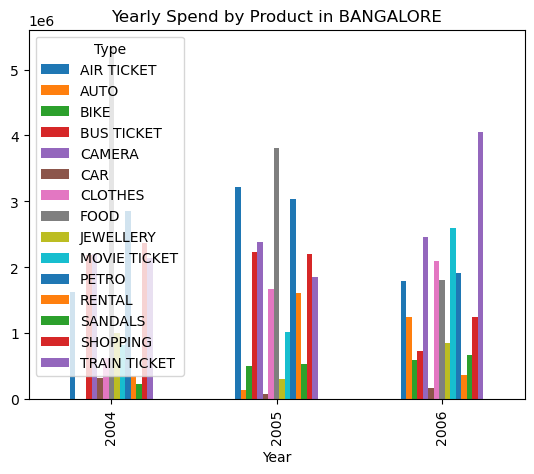

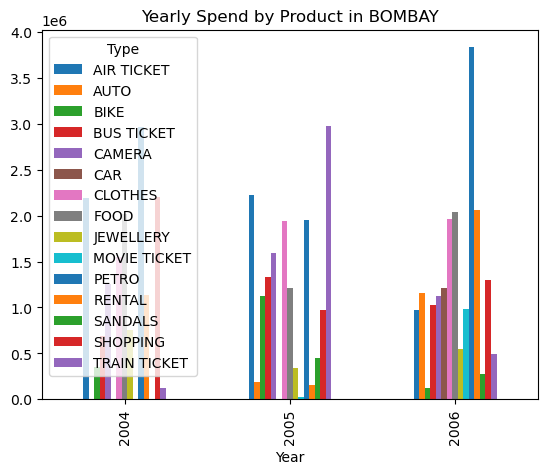

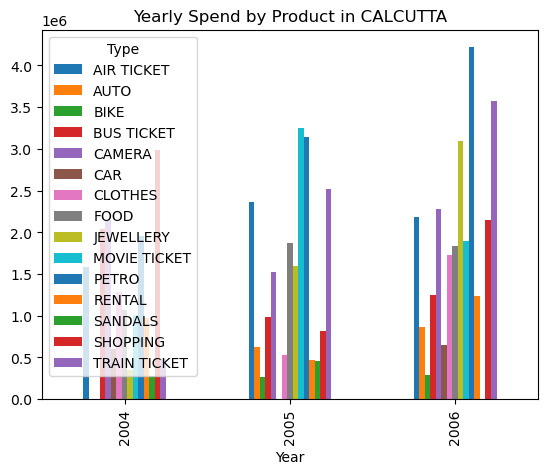

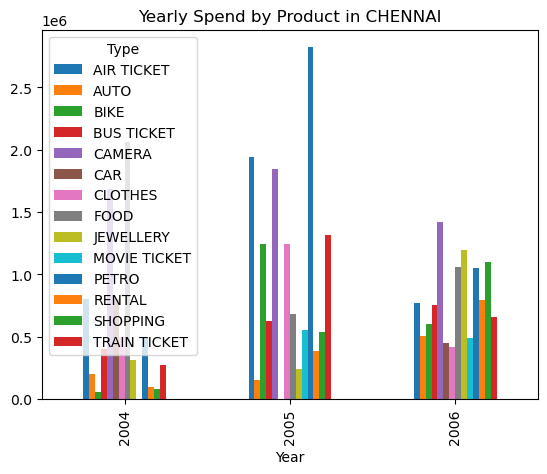

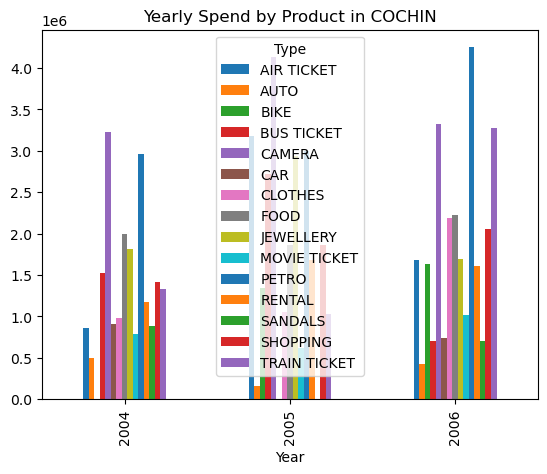

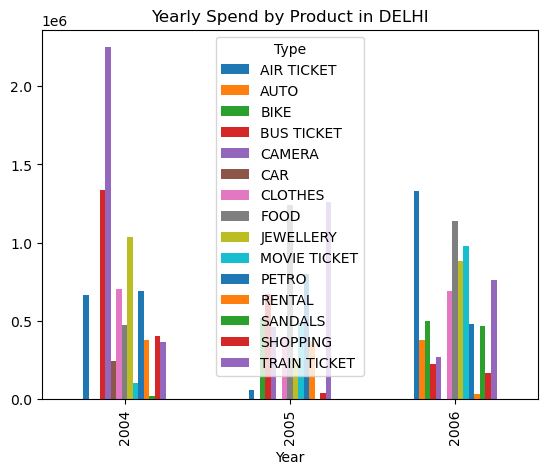

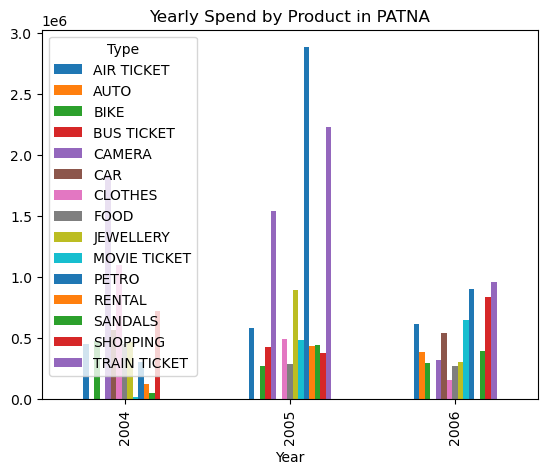

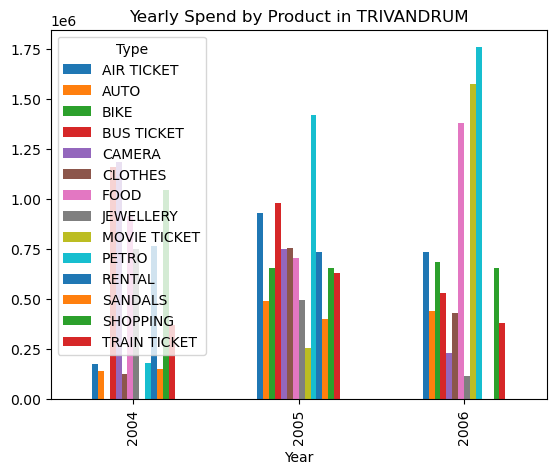

In [246]:
# Graphical Representation
for city in city_year_product["City"].unique():
    data = city_year_product[city_year_product["City"] == city]
    data.pivot(index="Year", columns="Type", values="Amount").plot(kind="bar")
    plt.title(f"Yearly Spend by Product in {city}")
    plt.show()


## 4. Create graphs for
#### a. Monthly comparison of total spends, city wise
#### b. Comparison of yearly spend on air tickets
#### c. Comparison of monthly spend for each product (look for any seasonality that exists in terms of spend)


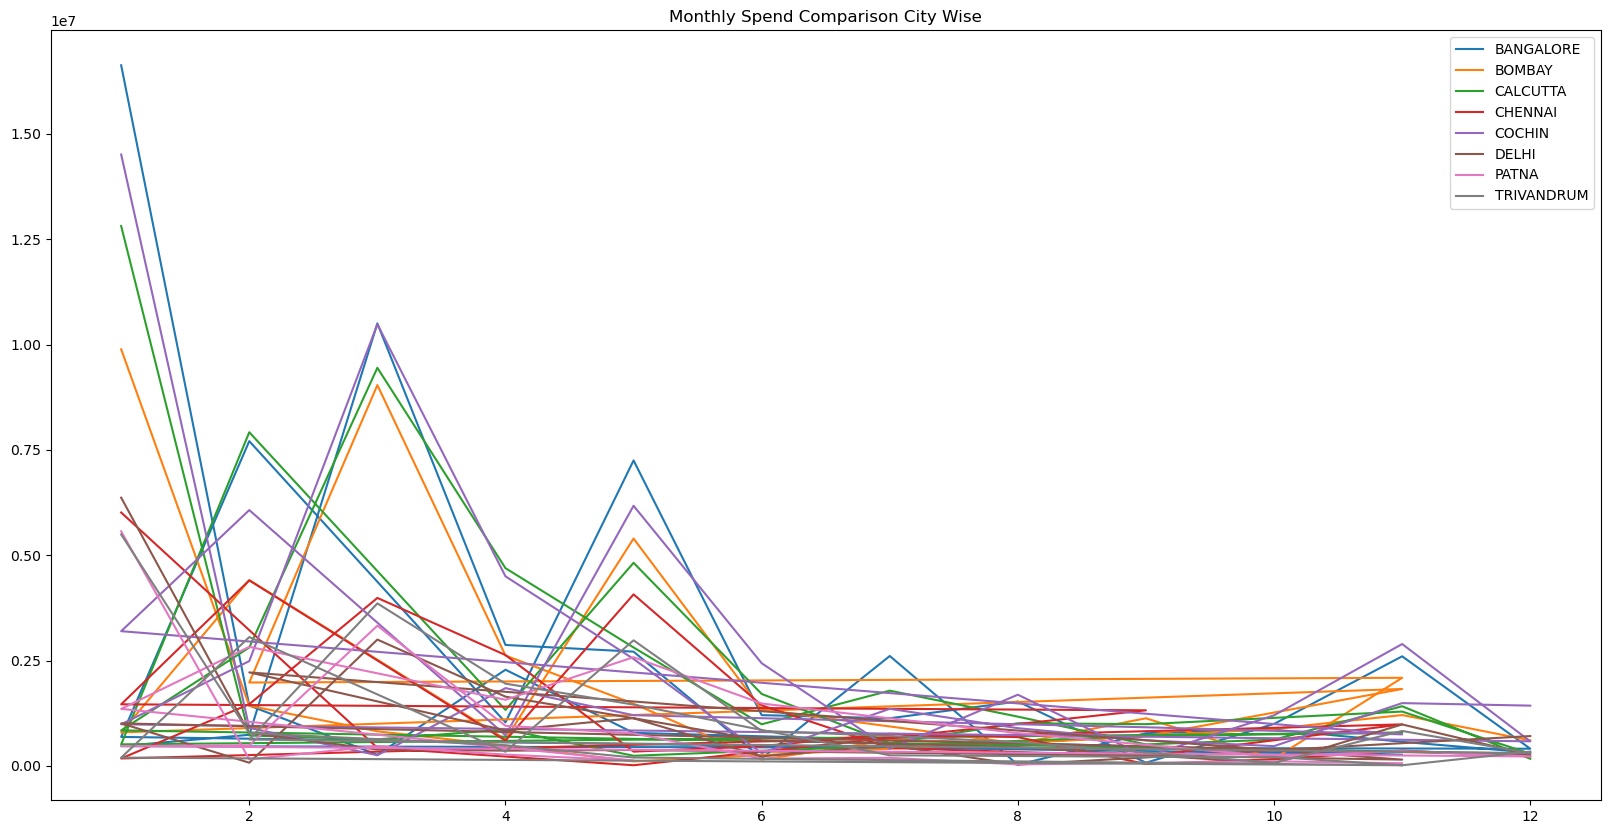

In [247]:
# a. Monthly comparison of total spends, city wise
plt.figure(figsize = (20,10))

monthly_city = spend_city.groupby(["City", "Year", "Month_num"])["Amount"].sum().reset_index()

for city in monthly_city["City"].unique():
    city_data = monthly_city[monthly_city["City"] == city]
    plt.plot(city_data["Month_num"], city_data["Amount"], label=city)
plt.legend()
plt.title("Monthly Spend Comparison City Wise")
plt.show()


In [248]:
air_spend.head()

,Sl No:,Customer,Month,Type,Amount,Year,Month_num
10,11,A11,2005-02-23,AIR TICKET,307622.01,2005,2
29,30,A30,2006-05-10,AIR TICKET,24399.98,2006,5
40,41,A41,2005-05-27,AIR TICKET,359764.34,2005,5
55,56,A56,2006-02-03,AIR TICKET,22463.65,2006,2
70,71,A69,2005-01-17,AIR TICKET,113339.36,2005,1


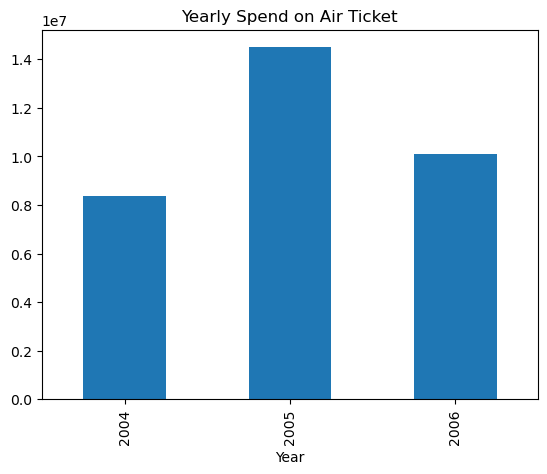

In [249]:
# b. Comparison of yearly spend on air tickets

air_spend.groupby("Year")["Amount"].sum().plot(kind="bar")
plt.title("Yearly Spend on Air Ticket")
plt.show()



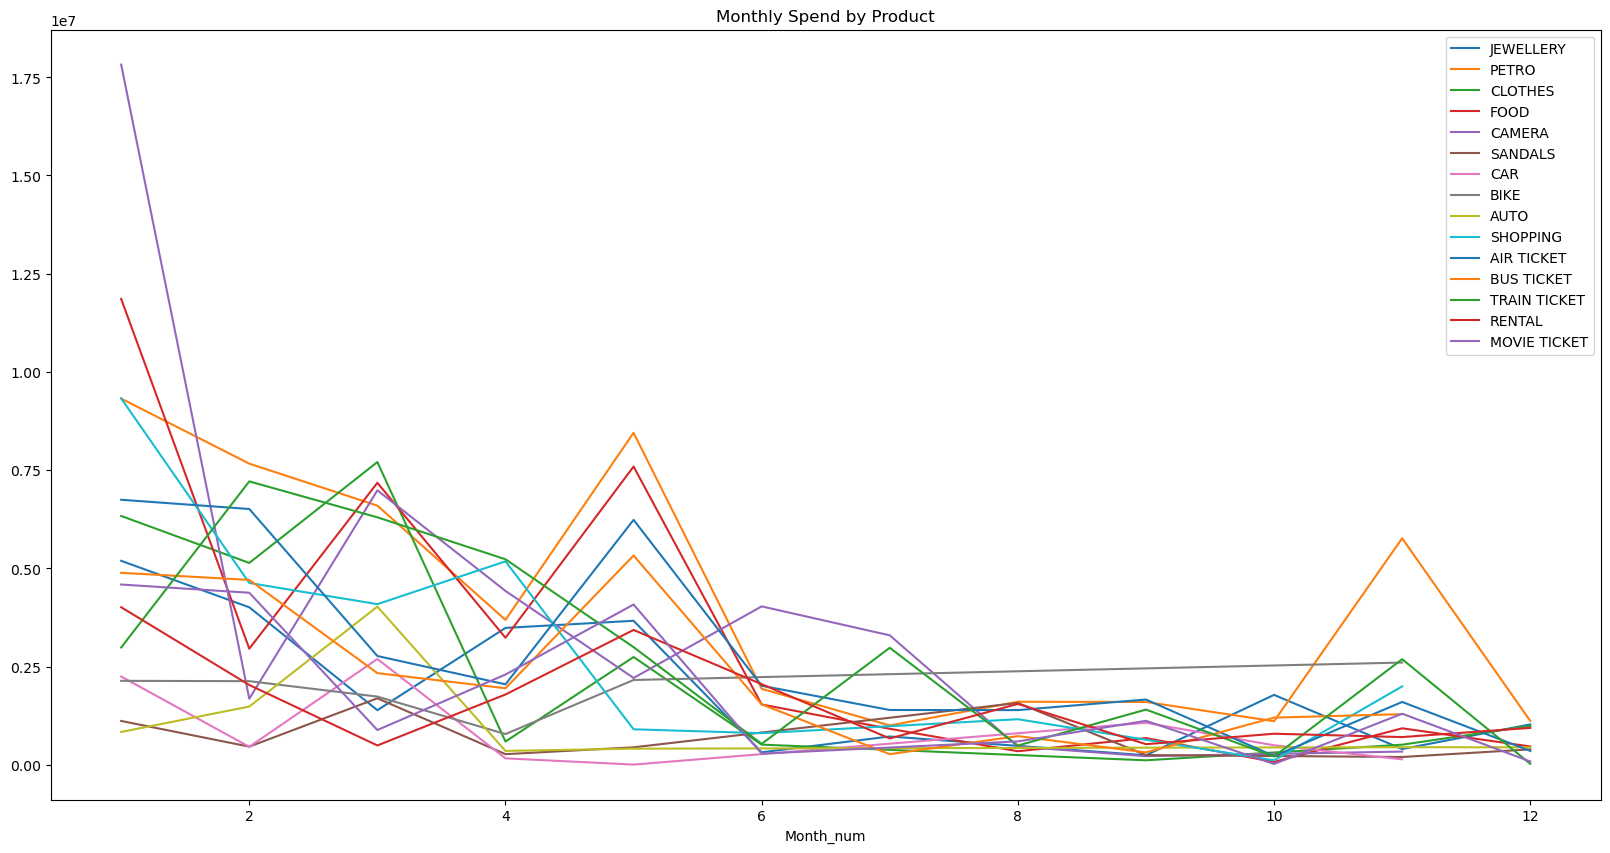

In [250]:
# c. Comparison of monthly spend for each product (look for any seasonality that exists in terms of spend)
plt.figure(figsize = (20,10))
for product in spn["Type"].unique():
    data = spn[spn["Type"] == product]
    data.groupby("Month_num")["Amount"].sum().plot(label=product)

plt.legend()
plt.title("Monthly Spend by Product")
plt.show()


## 5. Write user defined PYTHON function to perform the following analysis:
#### You need to find top 10 customers for each city in terms of their repayment amount by different products and by different time periods i.e. year or month. The user should be able to specify the product (Gold/Silver/Platinum) and time period (yearly or monthly) and the function should automatically take these inputs while identifying the top 10 customers.


In [251]:
def top_10_customers(city, product, period="yearly"):
    data = rep.merge(cust[["Customer", "City", "Product"]],on="Customer")
    data = data[(data["City"] == city) & (data["Product"] == product)]
    if period == "yearly":
        group_cols = ["Customer", "Year"]
    else:
        group_cols = ["Customer", "Year", "Month_num"]
    
    return (
        data.groupby(group_cols)["Amount"].sum().reset_index().sort_values("Amount", ascending=False).head(10))


In [252]:
top_10_customers("DELHI", "Gold", "monthly")

,Customer,Year,Month_num,Amount
6,A44,2005.0,5.0,1988158.24
0,A44,2004.0,1.0,1951360.74
10,A44,2006.0,3.0,696222.43
4,A44,2005.0,2.0,632243.90
7,A44,2005.0,8.0,539494.72
12,A44,2006.0,7.0,501962.99
3,A44,2005.0,1.0,464352.17
8,A44,2005.0,11.0,431079.67
16,A93,2004.0,1.0,342326.14
15,A82,2006.0,3.0,342200.74
